# QSVM 衣服辨識教學（Qiskit + sklearn）

 我們來嘗試不同的但類似的問題 `Fashion-MNIST` 資料集，先做最常見且容易理解的 **二元分類：衣服 vs 褲子**。


## 1️⃣ 安裝套件（Colab）




In [ ]:
!pip -q install "qiskit>=1.0" qiskit-aer qiskit-machine-learning scikit-learn matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00


## 2️⃣ 匯入必要函式庫
我們會用：
- `sklearn`：資料集、PCA、SVM、評估指標
- `qiskit` / `qiskit-machine-learning`：feature map 與 quantum kernel


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityStatevectorKernel


## 3️⃣ 載入衣服資料（digits）
用 mnist（28×28=784 維）示範

In [ ]:
from sklearn.datasets import fetch_openml

print("正在下載 MNIST 資料...")
#To do 1
mnist = fetch_openml('______', version=1, as_frame=False) #資料為Fashion-MNIST

# X_raw：影像資料
# shape = (70000, 784)
# 每張圖是 28×28 → 展平成 784 維向量
X_raw = mnist.data

# y_raw：標籤（0~9）
# 注意：這裡是字串型別，需要轉成 int
y_raw = mnist.target.astype(int)

print("原始資料 X shape:", X_raw.shape, "y shape:", y_raw.shape)
print("labels:", np.unique(y_raw))

正在下載 MNIST 資料...
原始資料 X shape: (70000, 784) y shape: (70000,)
labels: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw,
    #To do 2
    train_size=____,
    test_size=____,
    stratify=y_raw,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("訓練集 label 統計:", np.unique(y_train, return_counts=True))
print("測試集 label 統計:", np.unique(y_test, return_counts=True))

X_train shape: (1000, 784)
X_test shape: (250, 784)
訓練集 label 統計: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([100, 100, 100, 100, 100, 100, 100, 100, 100, 100]))
測試集 label 統計: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([25, 25, 25, 25, 25, 25, 25, 25, 25, 25]))


## 4️⃣ 選擇分類任務：衣服 vs 褲子（二元分類）


In [ ]:
#對每一筆資料，看它的 label 是不是 0(衣服) 或 1(褲子) 如果是，就標記 True；不是就 False。
mask = (y_raw == 0) | (y_raw == 1)
#只保留 mask 為 True 的那些樣本
X = X_raw[mask]
y = y_raw[mask]

print("二元分類後 X shape:", X.shape)
print("labels:", np.unique(y))

二元分類後 X shape: (14000, 784)
labels: [0 1]


## 5️⃣ 顯示幾張樣本圖
把 784 維向量 reshape 回 28×28，就能看到影像。

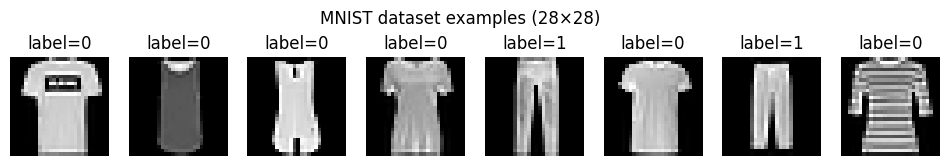

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"label={y[i]}")
    ax.axis("off")

plt.suptitle("MNIST dataset examples (28×28)")
plt.show()

## 6️⃣ 數據預處理（Scaling + PCA）
### 為什麼需要 PCA？
量子 feature map 通常假設：
- **qubit 數 = 特徵維度**

原始影像有 784 維，直接用 784 qubits 在模擬器上會非常慢。
因此我們用 PCA 降到 `n_qubits` 維（例如 6 或 8），保留主要資訊。

### 為什麼把資料縮放到 [0, π]？
因為 feature map 常用旋轉門（例如 RZ/RY），角度若落在合理區間，數值表現通常更穩定。

In [ ]:
#To do 3
n_qubits =_____    # 建議先 6 或 8，太大會變慢

# 1) 把 pixel data 縮放到 [0, 1]
X01 = MinMaxScaler().fit_transform(X)

# 2) PCA 降到 n_qubits 維
pca = PCA(n_components=n_qubits, random_state=0)
Xp = pca.fit_transform(X01)

# 3) 再縮放到 [0, π]，方便當旋轉角度
Xp = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(Xp)

# 分割 train/test
# 分割 train/test
from sklearn.model_selection import train_test_split
print(Xp.shape)
X_train, X_test, y_train, y_test = train_test_split(
    Xp, y,
#To do 4
    train_size=____,
    test_size=____,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

(14000, 6)
X_train: (1000, 6) X_test: (250, 6)


In [ ]:
#To do 5
def build_hea_feature_map(n_qubits, reps=1, entanglement="____"):
    x = ParameterVector("x", n_qubits)
    qc = QuantumCircuit(n_qubits)

    for r in range(reps):
        # data encoding layer
        #To do 6
        for i in range(n_qubits):
            qc_____.(x[i], i)
            qc____.(x[i], i)

        # entanglement layer
        if entanglement == "linear":
            for i in range(n_qubits - 1):
                qc.cx(i, i + 1)
        elif entanglement == "circular":
            for i in range(n_qubits - 1):
                qc.cx(i, i + 1)
            if n_qubits > 2:
                qc.cx(n_qubits - 1, 0)
        elif entanglement == "full":
            for i in range(n_qubits):
                for j in range(i + 1, n_qubits):
                    qc.cx(i, j)
        else:
            raise ValueError("entanglement must be 'linear', 'circular', or 'full'")

        if r < reps - 1:
            qc.barrier()

    return qc

feature_map = build_hea_feature_map(n_qubits=n_qubits, reps=, entanglement="linear")


In [ ]:

feature_map


In [ ]:
feature_map.decompose().draw("mpl", fold=100)
plt.show()


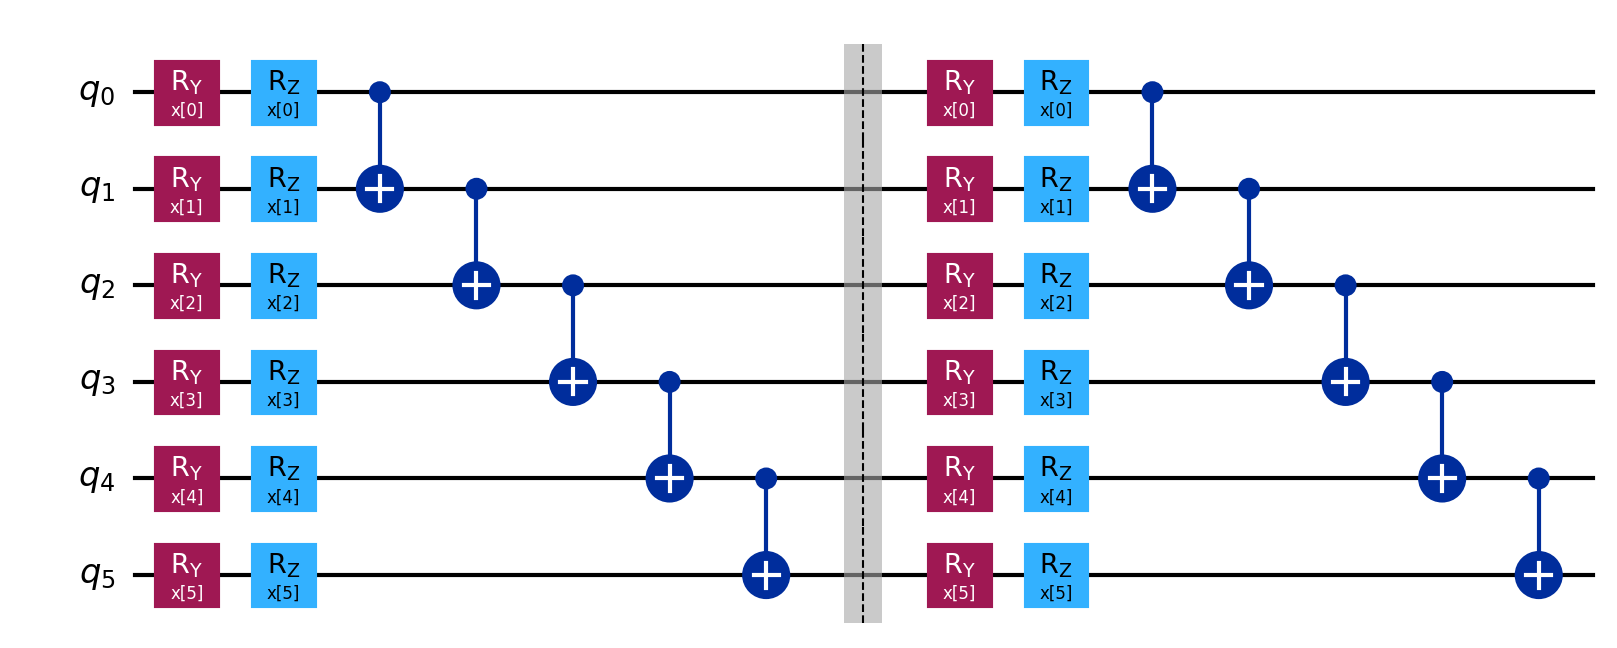

In [ ]:
#ZZ feature map電路圖
from IPython.display import Image, display

path = "feature_map.png"
feature_map.draw(output="mpl", fold=120, filename=path)

display(Image(filename=path))


## 8️⃣ 建立 Quantum Kernel（FidelityStatevectorKernel）
###  `FidelityStatevectorKernel`的定義如下:
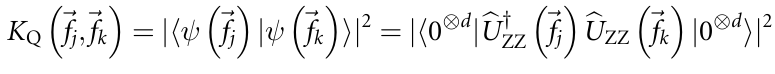

也就是將我們剛剛所構成的ZZ feature map作用在我們的qubites上具體的電路如下:

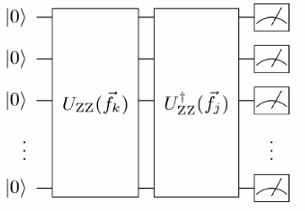

以此我們就可以構成我們的矩陣Kernel Matrix如下:

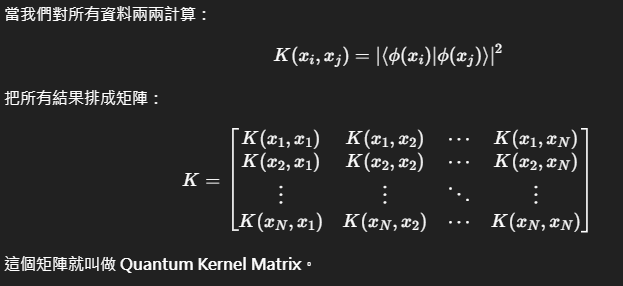

這個矩陣「每一格」代表第 i 筆資料 與 第 j 筆資料
在「量子特徵空間」中的相似度。

接近 1 → 非常像

接近 0 → 幾乎不相似

In [ ]:
qkernel = FidelityStatevectorKernel(feature_map=feature_map)
#計算「訓練資料彼此之間」的量子 kernel matrix
K_train = qkernel.evaluate(X_train)           # (N_train, N_train)

#計算「測試資料 對 訓練資料」的量子 kernel matrix
K_test  = qkernel.evaluate(X_test, X_train)   # (N_test,  N_train)

#確認矩陣維度
print("K_train:", K_train.shape, "K_test:", K_test.shape)

K_train: (1000, 1000) K_test: (250, 1000)


## 9️⃣ QSVM：用 kernel matrix 訓練  SVM
`sklearn.svm.SVC` 支援 precomputed kernel：
- 設定 `kernel='precomputed'`
- 直接把 K_train/K_test 丟進去

這樣就完成 QSVM。

In [ ]:
#我們不讓 SVM 自己算 kernel，而是「直接餵給它 kernel matrix」


clf = SVC(kernel="precomputed", C=1.0) #C=1.0是正則化參數，用來控制：分類錯誤的懲罰程度邊界的平滑程度

#用訓練資料的 kernel matrix + 標籤 來訓練 SVM
clf.fit(K_train, y_train)

#根據「測試資料與訓練資料的相似度」，預測每一筆測試資料屬於哪一類。
y_pred = clf.predict(K_test)

#比較：真實標籤 y_test預測標籤 y_pred算出分類正確率（Accuracy）。
acc = accuracy_score(y_test, y_pred)
print("QSVM Accuracy:", acc)


QSVM Accuracy: 0.98


## 🔟 結果評估：報告 + 混淆矩陣

如果我們將1 當作正類為例：

1. Precision （精確率）看的是在所有被模型判成 1 的樣本中，有幾個是真的 1算式如下:

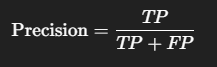

2.Recall 看的是在所有真的 1 裡面，有多少被模型成功找出來算式如下:

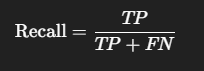

3.因為 Precision 和 Recall 常常會互相拉扯：

模型很保守 → Precision 高、Recall 低

模型很積極 → Recall 高、Precision 低

只看其中一個會失真，所以用 F1-score 把兩者綜合起來。

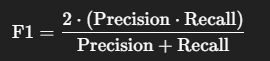

所以0當正類是類似的邏輯

Macro Average每一類別都當成同樣重要，先各自算指標，再取平均P為每個編號的機率

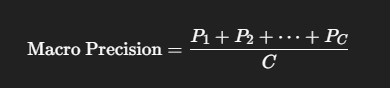

Weighted Average比起Macro Average多考慮了樣本數量

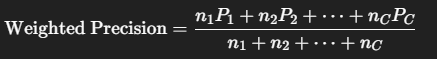

TN (True Negative)
真的是 0 → 預測成 0

FP (False Positive)
真的是 0 → 被誤判成 1

FN (False Negative)
真的是 1 → 被誤判成 0

TP (True Positive)
真的是 1 → 預測成 1

In [ ]:
print(classification_report(y_test, y_pred, digits=4))
#support為測試集中的數量0與1分別是45個

              precision    recall  f1-score   support

           0     0.9615    1.0000    0.9804       125
           1     1.0000    0.9600    0.9796       125

    accuracy                         0.9800       250
   macro avg     0.9808    0.9800    0.9800       250
weighted avg     0.9808    0.9800    0.9800       250



## 1️⃣1️⃣ 結果圖 ①：混淆矩陣熱圖
在二元分類時，confusion matrix 長這樣:

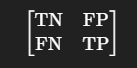

TN (True Negative)
真的是 0 → 預測成 0

FP (False Positive)
真的是 0 → 被誤判成 1

FN (False Negative)
真的是 1 → 被誤判成 0

TP (True Positive)
真的是 1 → 預測成 1

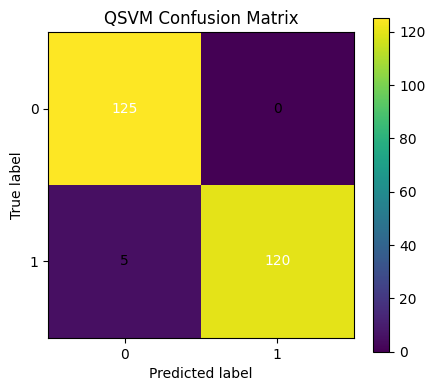

In [ ]:
cm = confusion_matrix(y_test, y_pred)
classes = ["0", "1"]

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("QSVM Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## 1️⃣2️⃣ 結果圖 ②：Quantum Kernel Matrix 熱圖
Quantum Kernel Matrix 熱圖是在顯示：
每一筆資料與其他所有資料之間的「量子相似度」。

顏色越亮 → 越像

顏色越暗 → 越不像


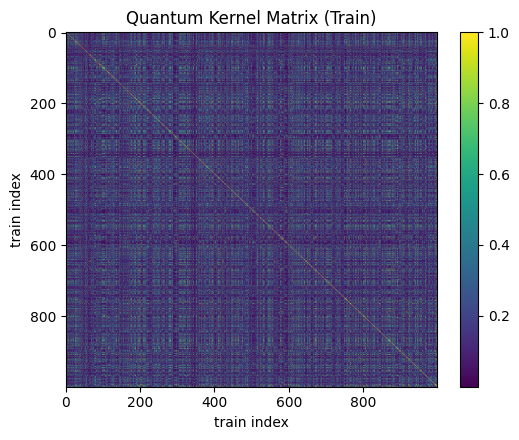

In [ ]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(K_train, aspect="auto")
plt.colorbar()
plt.title("Quantum Kernel Matrix (Train)")
plt.xlabel("train index")
plt.ylabel("train index")
plt.tight_layout()
plt.show()